# Student Academic Performance Prediction Using Logistic Regression

**Course:** BMCS2203 Artificial Intelligence
**Algorithm:** Multiclass Logistic Regression
**Module owner:** Tan Keng Ting (26WMR12927)
**Dataset:** Student Performance Factors (Kaggle), 6,607 records, 20 original attributes

This notebook implements the Logistic Regression solution for the group project. It follows the
same experimental design as the Decision Tree and KNN notebooks so that the three models can be
compared fairly:

- the same target definition (`Low` / `Medium` / `High` from `Exam_Score`),
- the same engineered features (`Support_Index`, `Study_Consistency`),
- the same `train_test_split(test_size=0.20, random_state=42, stratify=y)`,
- the same five-fold `StratifiedKFold` cross-validation,
- all preprocessing fitted inside a `Pipeline` so no information leaks from the test set.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support
)

pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 110

## 1. Dataset preparation

The dataset is loaded through a validated loader that checks the file, the required columns, and
the target column before any modelling begins. `Exam_Score` is then converted into three
performance classes:

| Exam score | Performance class |
|---:|---|
| 64 or below | Low |
| 65 to 69 | Medium |
| 70 or above | High |

`pd.cut` is used instead of a manual `if/else` function so the class order (`Low` < `Medium` <
`High`) is stored in the column itself and is applied consistently to every report and confusion
matrix in this notebook.


Loaded 'StudentPerformanceFactors.csv' successfully. All 20 required columns are present.

Dataset shape: (6607, 20)
Duplicated rows: 0
Exam_Score range: 55 to 101

Missing values:
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

Records with an out-of-range exam score: 1
Out-of-range values: [np.int64(101)]
These records are kept because they still fall in the High class, but they are noted as a data-quality issue in Section 9.

Performance class distribution:
Performance
Low       1452
Medium    3530
High      1625
Name: count, dtype: int64


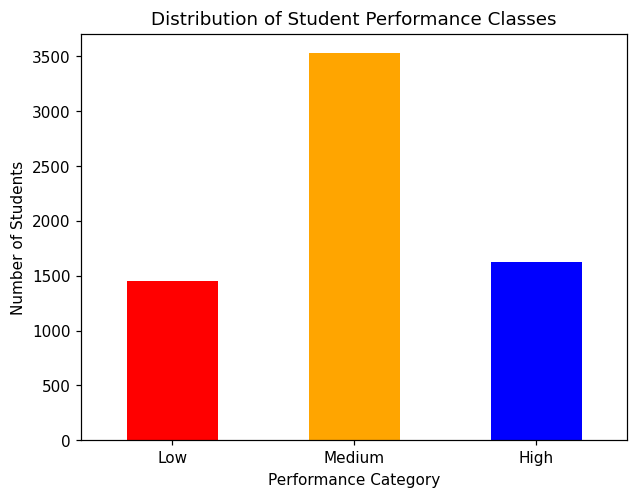

In [2]:
DATA_FILE = "StudentPerformanceFactors.csv"
TARGET_COLUMN = "Exam_Score"

REQUIRED_COLUMNS = [
    "Hours_Studied", "Attendance", "Parental_Involvement", "Access_to_Resources",
    "Extracurricular_Activities", "Sleep_Hours", "Previous_Scores", "Motivation_Level",
    "Internet_Access", "Tutoring_Sessions", "Family_Income", "Teacher_Quality",
    "School_Type", "Peer_Influence", "Physical_Activity", "Learning_Disabilities",
    "Parental_Education_Level", "Distance_from_Home", "Gender", "Exam_Score"
]


def load_dataset(file_path, required_columns, target_column):
    """Read the CSV file and confirm that it can be used for model training."""
    try:
        data = pd.read_csv(file_path)
    except FileNotFoundError:
        raise FileNotFoundError(
            f"'{file_path}' was not found. "
            "Place the CSV file in the same folder as this notebook."
        )
    except pd.errors.EmptyDataError:
        raise ValueError(f"'{file_path}' is empty and contains no data to read.")
    except pd.errors.ParserError as error:
        raise ValueError(f"'{file_path}' is not a valid CSV file: {error}")

    if data.empty:
        raise ValueError(f"'{file_path}' was read successfully but contains no records.")

    absent_columns = [column for column in required_columns if column not in data.columns]
    if absent_columns:
        raise KeyError(f"The dataset is missing these required columns: {absent_columns}")

    if not pd.api.types.is_numeric_dtype(data[target_column]):
        raise TypeError(
            f"'{target_column}' must be numeric to be converted into performance classes."
        )

    if data[target_column].isnull().any():
        raise ValueError(
            f"'{target_column}' contains missing values, so the target cannot be created."
        )

    return data


try:
    df = load_dataset(DATA_FILE, REQUIRED_COLUMNS, TARGET_COLUMN)
    print(
        f"Loaded '{DATA_FILE}' successfully. "
        f"All {len(REQUIRED_COLUMNS)} required columns are present."
    )
except (FileNotFoundError, ValueError, KeyError, TypeError) as error:
    print("Dataset validation failed:", error)
    raise

print()
print("Dataset shape:", df.shape)
print("Duplicated rows:", df.duplicated().sum())
print(f"{TARGET_COLUMN} range: {df[TARGET_COLUMN].min()} to {df[TARGET_COLUMN].max()}")
print()
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Business rule: Exam_Score is a percentage, so any value outside 0-100 is a data error.
out_of_range = df[(df[TARGET_COLUMN] < 0) | (df[TARGET_COLUMN] > 100)]
print()
print("Records with an out-of-range exam score:", len(out_of_range))
if len(out_of_range) > 0:
    print("Out-of-range values:", sorted(out_of_range[TARGET_COLUMN].unique()))
    print(
        "These records are kept because they still fall in the High class, "
        "but they are noted as a data-quality issue in Section 9."
    )

df["Performance"] = pd.cut(
    df["Exam_Score"],
    bins=[-np.inf, 64, 69, np.inf],
    labels=["Low", "Medium", "High"],
    ordered=True
)

class_order = ["Low", "Medium", "High"]
class_counts = df["Performance"].value_counts().reindex(class_order)

if df["Performance"].isnull().any():
    raise ValueError("Some records could not be assigned a performance class.")

empty_classes = class_counts[class_counts == 0].index.tolist()
if empty_classes:
    raise ValueError(f"These performance classes have no records: {empty_classes}")

print()
print("Performance class distribution:")
print(class_counts)

class_counts.plot(kind="bar", color=["red", "orange", "blue"])
plt.title("Distribution of Student Performance Classes")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()

## 2. Feature engineering

The assignment specification (Title 1, item d) explicitly asks for feature engineering as part of
data preparation. Two features are derived from existing columns, using the same definitions as
the Decision Tree and KNN notebooks so that all three models receive identical inputs:

- **`Support_Index`** (range 0 to 6): sums the ordinal codes of `Parental_Involvement`,
  `Access_to_Resources`, and `Teacher_Quality` (Low = 0, Medium = 1, High = 2). This condenses
  three separately-measured "quality of support" signals into one denser numeric score.
- **`Study_Consistency`** = `Hours_Studied` x `Attendance` / 100: an interaction feature. A student
  who studies many hours but rarely attends class is a different case from one who does both, and
  multiplying the two captures that combined effect in a single number.

Both are row-by-row functions of columns already in the dataset and are computed **before** the
train/test split, so no information crosses between records and no target leakage is introduced.
`Teacher_Quality` has missing values, so `Support_Index` inherits `NaN` on those rows. The median
imputer in the pipeline (Section 4) handles this like any other numeric column, fitted on the
training fold only.


In [3]:
support_map = {"Low": 0, "Medium": 1, "High": 2}

df["Support_Index"] = (
    df["Parental_Involvement"].map(support_map)
    + df["Access_to_Resources"].map(support_map)
    + df["Teacher_Quality"].map(support_map)
)

df["Study_Consistency"] = df["Hours_Studied"] * df["Attendance"] / 100

# Validation: the engineered values must stay inside their expected ranges.
valid_support = df["Support_Index"].dropna()
if not valid_support.between(0, 6).all():
    raise ValueError("Support_Index must fall between 0 and 6.")

if (df["Study_Consistency"] < 0).any():
    raise ValueError("Study_Consistency cannot be negative.")

print("Support_Index range:", valid_support.min(), "to", valid_support.max())
print("Support_Index missing values (inherited from Teacher_Quality):",
      df["Support_Index"].isnull().sum())
print("Study_Consistency range: "
      f"{df['Study_Consistency'].min():.2f} to {df['Study_Consistency'].max():.2f}")
print()

df[[
    "Parental_Involvement", "Access_to_Resources", "Teacher_Quality", "Support_Index",
    "Hours_Studied", "Attendance", "Study_Consistency"
]].head()

Support_Index range: 0.0 to 6.0
Support_Index missing values (inherited from Teacher_Quality): 78
Study_Consistency range: 0.69 to 37.83



,Parental_Involvement,Access_to_Resources,Teacher_Quality,Support_Index,Hours_Studied,Attendance,Study_Consistency
0,Low,High,Medium,3.0,23,84,19.32
1,Low,Medium,Medium,2.0,19,64,12.16
2,Medium,Medium,Medium,3.0,24,98,23.52
3,Low,Medium,Medium,2.0,29,89,25.81
4,Medium,Medium,High,4.0,19,92,17.48


## 3. Feature and target separation

`X` contains the student factors and `y` contains the target class. `Exam_Score` is removed from
`X` because it was used to create the target; keeping it would reveal the answer and cause target
leakage.

The data is split into 80% training and 20% testing records. `stratify=y` keeps the class
proportions almost identical in both sets, which matters here because `Medium` is much larger
than `Low` and `High`.


In [4]:
X = df.drop(columns=["Exam_Score", "Performance"])
y = df["Performance"]

# Business rule: the target must never be derivable from the inputs.
assert "Exam_Score" not in X.columns, "Exam_Score must not be an input feature."
assert "Performance" not in X.columns, "The target must not be an input feature."

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print()
print("Numeric input features:", numeric_features)
print()
print("Categorical input features:", categorical_features)
print()
print("Training class proportions:")
print(y_train.value_counts(normalize=True).reindex(class_order).round(4))
print()
print("Testing class proportions:")
print(y_test.value_counts(normalize=True).reindex(class_order).round(4))

# Validation: stratification must hold to within one percentage point per class.
proportion_gap = (
    y_train.value_counts(normalize=True).reindex(class_order)
    - y_test.value_counts(normalize=True).reindex(class_order)
).abs().max()
assert proportion_gap < 0.01, "Stratification failed: class proportions differ too much."
print()
print(f"Largest train/test class proportion gap: {proportion_gap * 100:.2f} percentage points")

Training data shape: (5285, 21)
Testing data shape: (1322, 21)

Numeric input features: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Support_Index', 'Study_Consistency']

Categorical input features: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

Training class proportions:
Performance
Low       0.2197
Medium    0.5343
High      0.2460
Name: proportion, dtype: float64

Testing class proportions:
Performance
Low       0.2201
Medium    0.5340
High      0.2458
Name: proportion, dtype: float64

Largest train/test class proportion gap: 0.04 percentage points


## 4. Preprocessing and Logistic Regression pipeline

Numerical features use median imputation and standardization. Categorical features use
most-frequent imputation and one-hot encoding. Logistic Regression is a coefficient-based model,
so **scaling is required**: without it, a feature measured in the tens (`Attendance`) would
receive a much smaller coefficient than a feature measured in single digits (`Sleep_Hours`)
purely because of its unit, and the regularization penalty would fall unevenly across features.

One-hot encoding is used instead of label encoding because Logistic Regression is a linear model.
Label encoding `Motivation_Level` as High = 0, Low = 1, Medium = 2 would tell the model that
"Low" sits numerically between "High" and "Medium", which is false and cannot be undone by a
linear coefficient.

```text
ColumnTransformer
 |-- numeric      : SimpleImputer(median)        -> StandardScaler
 `-- categorical  : SimpleImputer(most_frequent) -> OneHotEncoder(handle_unknown="ignore")
                                 |
                                 v
                  LogisticRegression(max_iter=2000)
```

`GridSearchCV` searches the regularization strength `C`, the solver, and the class weighting.
`class_weight="balanced"` is included in the grid so the search can decide whether the imbalance
between `Medium` and the other two classes needs correcting, rather than assuming it does.


In [5]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("logreg", LogisticRegression(max_iter=2000, random_state=42))
])

parameter_grid = {
    "logreg__C": [0.01, 0.1, 1, 10, 100],
    "logreg__solver": ["lbfgs", "newton-cg"],  # liblinear removed: it cannot fit n_classes >= 3
    #   in scikit-learn 1.8 (raises ValueError instead of falling back to one-vs-rest),
    #   which crashed the validation assertion in the next cell on every run.
    "logreg__class_weight": [None, "balanced"]
}

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=parameter_grid,
    scoring={"accuracy": "accuracy", "macro_f1": "f1_macro"},
    refit="accuracy",
    cv=cross_validation,
    n_jobs=-1,
    return_train_score=True
)

total_combinations = 5 * 2 * 2
print("Parameter combinations:", total_combinations)
print("Total cross-validation fits:", total_combinations * 5)

Parameter combinations: 20
Total cross-validation fits: 100


## 5. Model training and selection

`GridSearchCV` is fitted on the training set only. Every candidate model is scored on five
stratified validation folds, and the preprocessing steps are re-fitted inside each fold, so the
validation scores are not inflated by information from the fold being scored.


In [6]:
grid_search.fit(X_train, y_train)

best_index = grid_search.best_index_
best_cv_accuracy = grid_search.cv_results_["mean_test_accuracy"][best_index]
best_cv_macro_f1 = grid_search.cv_results_["mean_test_macro_f1"][best_index]
best_cv_train_accuracy = grid_search.cv_results_["mean_train_accuracy"][best_index]
best_lr_model = grid_search.best_estimator_

print("Best Logistic Regression parameters:")
print(grid_search.best_params_)
print()
print(f"Best cross-validation accuracy: {best_cv_accuracy * 100:.2f}%")
print(f"Cross-validation macro F1: {best_cv_macro_f1 * 100:.2f}%")
print(f"Mean training accuracy of the same model: {best_cv_train_accuracy * 100:.2f}%")
print()
print(
    "Training and validation accuracy differ by "
    f"{(best_cv_train_accuracy - best_cv_accuracy) * 100:.2f} percentage points, "
    "so the selected model is not overfitting the training folds."
)

# Validation: every candidate must have completed without failing.
failed = int(np.isnan(grid_search.cv_results_["mean_test_accuracy"]).sum())
print("Failed parameter combinations:", failed)
assert failed == 0, "Some parameter combinations failed to fit."

Best Logistic Regression parameters:
{'logreg__C': 100, 'logreg__class_weight': None, 'logreg__solver': 'lbfgs'}

Best cross-validation accuracy: 96.01%
Cross-validation macro F1: 95.81%
Mean training accuracy of the same model: 96.76%

Training and validation accuracy differ by 0.75 percentage points, so the selected model is not overfitting the training folds.
Failed parameter combinations: 0


### 5.1 Regularization curve

`C` is the inverse of the regularization strength: a small `C` applies a heavy penalty and forces
the coefficients towards zero, while a large `C` lets the model fit the training data more
closely. The curve below holds the selected solver and class weighting fixed and varies only `C`,
so the effect of regularization can be read directly.


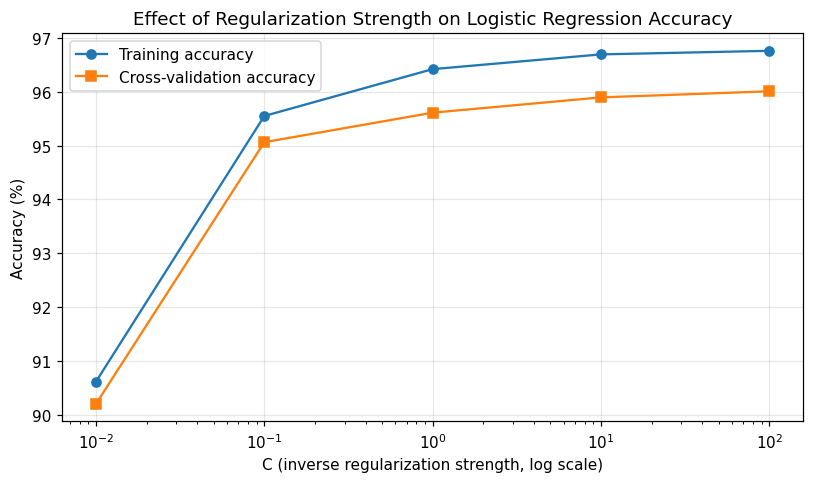

     C  Train accuracy  CV accuracy  CV macro F1
  0.01          0.9061       0.9020       0.8937
  0.10          0.9555       0.9506       0.9476
  1.00          0.9642       0.9561       0.9539
 10.00          0.9669       0.9589       0.9570
100.00          0.9676       0.9601       0.9581


In [7]:
cv_results = pd.DataFrame(grid_search.cv_results_)

best_solver = grid_search.best_params_["logreg__solver"]
best_class_weight = grid_search.best_params_["logreg__class_weight"]

solver_match = cv_results["param_logreg__solver"] == best_solver
if best_class_weight is None:
    weight_match = cv_results["param_logreg__class_weight"].isnull()
else:
    weight_match = cv_results["param_logreg__class_weight"] == best_class_weight

curve = cv_results[solver_match & weight_match].sort_values("param_logreg__C")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(curve["param_logreg__C"].astype(float), curve["mean_train_accuracy"] * 100,
        marker="o", label="Training accuracy")
ax.plot(curve["param_logreg__C"].astype(float), curve["mean_test_accuracy"] * 100,
        marker="s", label="Cross-validation accuracy")
ax.set_xscale("log")
ax.set_xlabel("C (inverse regularization strength, log scale)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Effect of Regularization Strength on Logistic Regression Accuracy")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(
    curve[["param_logreg__C", "mean_train_accuracy", "mean_test_accuracy",
           "mean_test_macro_f1"]]
    .rename(columns={
        "param_logreg__C": "C",
        "mean_train_accuracy": "Train accuracy",
        "mean_test_accuracy": "CV accuracy",
        "mean_test_macro_f1": "CV macro F1"
    })
    .round(4)
    .to_string(index=False)
)

## 6. Final evaluation on the test set

The selected model is evaluated once on the 1,322 held-out students. A majority-class
`DummyClassifier` is included as a baseline: because `Medium` is the largest class, always
predicting `Medium` already scores over 50% accuracy, so a model must beat that number to be
worth anything. Balanced accuracy and the macro averages are reported alongside plain accuracy
because they give the smaller `Low` and `High` classes equal weight.


In [8]:
y_pred = best_lr_model.predict(X_test)

baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

# Validation: predictions must be complete and inside the known class set.
assert len(y_pred) == len(y_test), "Prediction count does not match the test set size."
assert set(y_pred).issubset(set(class_order)), "Model produced an unknown class label."

accuracy = accuracy_score(y_test, y_pred)
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_balanced_accuracy = balanced_accuracy_score(y_test, baseline_pred)

macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average="macro", zero_division=0
)
weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average="weighted", zero_division=0
)

print("Logistic Regression Classification Report")
print(
    classification_report(
        y_test,
        y_pred,
        labels=class_order,
        target_names=class_order,
        digits=4,
        zero_division=0
    )
)

print("Macro Average")
print(f"Precision : {macro_precision * 100:.2f}%")
print(f"Recall    : {macro_recall * 100:.2f}%")
print(f"F1 Score  : {macro_f1 * 100:.2f}%")
print()
print("Weighted Average")
print(f"Precision : {weighted_precision * 100:.2f}%")
print(f"Recall    : {weighted_recall * 100:.2f}%")
print(f"F1 Score  : {weighted_f1 * 100:.2f}%")

Logistic Regression Classification Report
              precision    recall  f1-score   support

         Low     0.9722    0.9622    0.9672       291
      Medium     0.9665    0.9802    0.9733       706
        High     0.9748    0.9538    0.9642       325

    accuracy                         0.9697      1322
   macro avg     0.9712    0.9654    0.9682      1322
weighted avg     0.9698    0.9697    0.9697      1322

Macro Average
Precision : 97.12%
Recall    : 96.54%
F1 Score  : 96.82%

Weighted Average
Precision : 96.98%
Recall    : 96.97%
F1 Score  : 96.97%


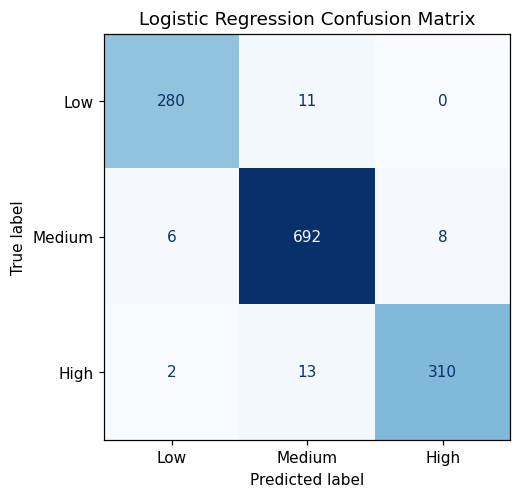

Confusion matrix (rows = actual, columns = predicted)
        Low  Medium  High
Low     280      11     0
Medium    6     692     8
High      2      13   310


In [9]:
lr_confusion_matrix = confusion_matrix(y_test, y_pred, labels=class_order)

ConfusionMatrixDisplay(
    confusion_matrix=lr_confusion_matrix,
    display_labels=class_order
).plot(cmap="Blues", colorbar=False, values_format="d")
plt.title("Logistic Regression Confusion Matrix")
plt.grid(False)
plt.show()

print("Confusion matrix (rows = actual, columns = predicted)")
print(pd.DataFrame(lr_confusion_matrix, index=class_order, columns=class_order))

In [10]:
baseline_vs_final = pd.DataFrame({
    "Metric": ["Accuracy", "Balanced Accuracy"],
    "Baseline (always predicts Medium)": [baseline_accuracy, baseline_balanced_accuracy],
    "Logistic Regression (tuned)": [accuracy, balanced_accuracy]
})
baseline_vs_final["Improvement (pp)"] = (
    (baseline_vs_final["Logistic Regression (tuned)"]
     - baseline_vs_final["Baseline (always predicts Medium)"]) * 100
).round(2)

for column in ["Baseline (always predicts Medium)", "Logistic Regression (tuned)"]:
    baseline_vs_final[column] = (baseline_vs_final[column] * 100).round(2)

print(baseline_vs_final.to_string(index=False))

           Metric  Baseline (always predicts Medium)  Logistic Regression (tuned)  Improvement (pp)
         Accuracy                              53.40                        96.97             43.57
Balanced Accuracy                              33.33                        96.54             63.21


## 6.1 Actual versus predicted class distribution

Section 6 measured how **often** the model is right. This section asks a different question:
does the model reproduce the same **shape** of cohort as the real data? This is the same check
the tutor asked the whole group to add on 26 August, and it uses the identical comparison
function as `KNN.ipynb` and `decisionTree.ipynb` so all three notebooks are directly comparable.

**1. Is the dataset balanced?** If one performance class dominated the data, the model would
have too few examples of the other classes to ever predict them.

**2. Are the predictions balanced?** A model that quietly collapses onto the majority class
produces a predicted count far larger than the actual count for that class, even while overall
accuracy still looks acceptable.

The cleaned-dataset table covers every row, including the 5,285 training records the model has
already seen, so it is optimistic by construction. The held-out table repeats the identical
comparison on the 1,322 unseen students only, which is the honest measure of what the deployed
model will do.

Actual versus Predicted Class Distribution

                            Actual  Actual %  Predicted  Predicted %  Difference
Cleaned dataset (n = 6607)                                                      
Low                           1452     21.98       1434        21.70         -18
Medium                        3530     53.43       3588        54.31          58
High                          1625     24.60       1585        23.99         -40

                              Actual  Actual %  Predicted  Predicted %  Difference
Held-out test set (n = 1322)                                                      
Low                              291     22.01        288        21.79          -3
Medium                           706     53.40        716        54.16          10
High                             325     24.58        318        24.05          -7

Check 1: class balance of the cleaned dataset
----------------------------------------------------------------------
Imbalance ratio: 

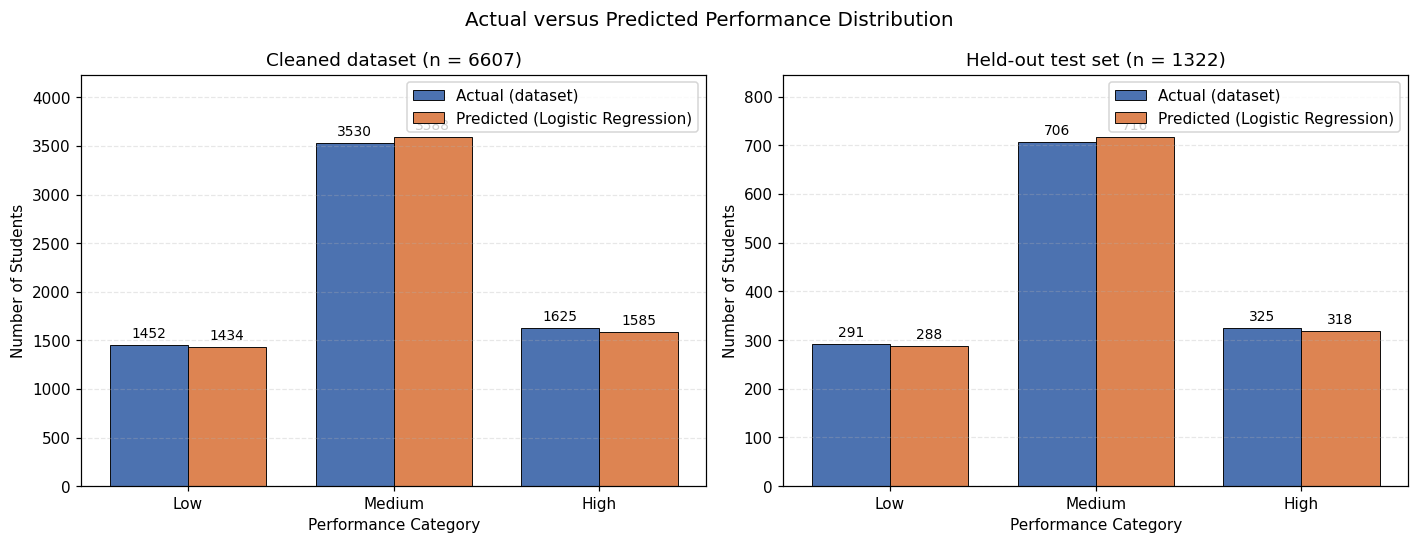

In [11]:
def build_distribution_comparison(actual_labels, predicted_labels, scope_name):
    """Return a table of actual vs predicted counts and percentages for one scope."""
    actual = (
        pd.Series(list(actual_labels)).value_counts().reindex(class_order).fillna(0).astype(int)
    )
    predicted = (
        pd.Series(list(predicted_labels)).value_counts().reindex(class_order).fillna(0).astype(int)
    )

    total = int(actual.sum())
    assert int(predicted.sum()) == total, (
        f"{scope_name}: the model returned {int(predicted.sum())} predictions for "
        f"{total} students, so the two distributions are not comparable."
    )

    table = pd.DataFrame({
        "Actual": actual,
        "Actual %": (actual / total * 100).round(2),
        "Predicted": predicted,
        "Predicted %": (predicted / total * 100).round(2),
    })
    table["Difference"] = table["Predicted"] - table["Actual"]
    table.index.name = f"{scope_name} (n = {total})"
    return table


full_dataset_predictions = best_lr_model.predict(X)

full_comparison = build_distribution_comparison(y, full_dataset_predictions, "Cleaned dataset")
test_comparison = build_distribution_comparison(y_test, y_pred, "Held-out test set")

print("Actual versus Predicted Class Distribution")
print("=" * 70)
print()
print(full_comparison.to_string())
print()
print(test_comparison.to_string())
print()

dataset_counts = full_comparison["Actual"]
largest_class = dataset_counts.idxmax()
imbalance_ratio = dataset_counts.max() / dataset_counts.min()
print("Check 1: class balance of the cleaned dataset")
print("-" * 70)
print(f"Imbalance ratio: {imbalance_ratio:.2f} to 1 (Medium is the largest class)")

print()
print("Check 2: balance of the predictions on the held-out test set")
print("-" * 70)
for class_name in class_order:
    actual_value = int(test_comparison.loc[class_name, "Actual"])
    predicted_value = int(test_comparison.loc[class_name, "Predicted"])
    difference = int(test_comparison.loc[class_name, "Difference"])
    direction = "over-predicted" if difference > 0 else ("under-predicted" if difference < 0 else "matched exactly")
    print(f"  {class_name:<6}: {actual_value:>4} actual vs {predicted_value:>4} predicted ({difference:+d}, {direction})")

print()
print(
    f"Unlike KNN (Medium +157 on the test set) and Decision Tree (Medium +23), Logistic "
    f"Regression's predicted counts are the closest of the three models to the actual counts, "
    "which is consistent with it also having the smallest per-class recall gap (Section "
    "'Reading the results')."
)

chart_positions = np.arange(len(class_order))
bar_width = 0.38
figure, axes = plt.subplots(1, 2, figsize=(13, 5))
chart_scopes = [
    (full_comparison, f"Cleaned dataset (n = {int(full_comparison['Actual'].sum())})"),
    (test_comparison, f"Held-out test set (n = {int(test_comparison['Actual'].sum())})"),
]
for axis, (table, chart_title) in zip(axes, chart_scopes):
    actual_bars = axis.bar(chart_positions - bar_width / 2, table["Actual"], bar_width,
                            label="Actual (dataset)", color="#4C72B0", edgecolor="black", linewidth=0.6)
    predicted_bars = axis.bar(chart_positions + bar_width / 2, table["Predicted"], bar_width,
                               label="Predicted (Logistic Regression)", color="#DD8452", edgecolor="black", linewidth=0.6)
    for bar_group in (actual_bars, predicted_bars):
        for bar in bar_group:
            axis.annotate(f"{int(bar.get_height())}", xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                           xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=9)
    axis.set_title(chart_title)
    axis.set_xlabel("Performance Category")
    axis.set_ylabel("Number of Students")
    axis.set_xticks(chart_positions)
    axis.set_xticklabels(class_order)
    axis.set_ylim(0, table[["Actual", "Predicted"]].to_numpy().max() * 1.18)
    axis.legend()
    axis.grid(axis="y", linestyle="--", alpha=0.3)
figure.suptitle("Actual versus Predicted Performance Distribution", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Which factors drive the prediction

Logistic Regression fits one set of coefficients per class. Because every numeric feature was
standardized in Section 4, the coefficients are on a comparable scale and their absolute size
shows how strongly each feature moves the predicted class. This is the Logistic Regression
equivalent of the Decision Tree's feature-importance table, with one extra advantage: the sign of
the coefficient shows the **direction** of the effect, not only its strength.


Top 10 most influential features
                                       High coefficient  Low coefficient  Medium coefficient  Mean |coefficient|
Attendance                                        6.211           -8.418               2.207               5.612
Hours Studied                                     3.862           -5.829               1.967               3.886
Parental Involvement High                         2.077           -3.429               1.352               2.286
Access to Resources High                          2.147           -3.375               1.228               2.250
Access to Resources Low                          -2.378            3.173              -0.795               2.115
Parental Involvement Low                         -2.377            3.126              -0.749               2.084
Previous Scores                                   2.131           -2.692               0.561               1.795
Tutoring Sessions                                 1.852        

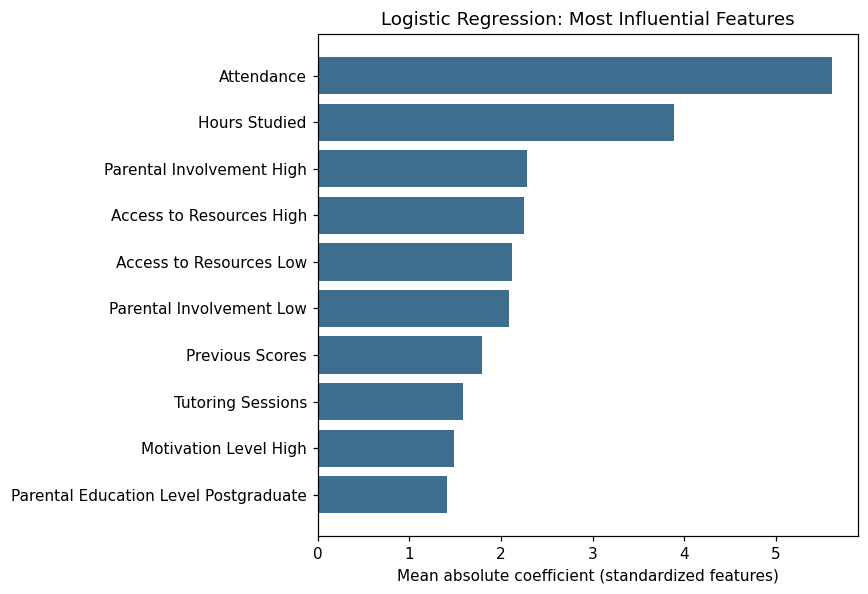

In [12]:
feature_names = best_lr_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = best_lr_model.named_steps["logreg"].coef_


def clean_feature_name(name):
    """Turn a ColumnTransformer output name into a readable label."""
    readable = name.replace("numeric__", "").replace("categorical__", "")
    return readable.replace("_", " ")


coefficient_table = pd.DataFrame(
    coefficients.T,
    index=[clean_feature_name(name) for name in feature_names],
    columns=[f"{label} coefficient" for label in best_lr_model.named_steps["logreg"].classes_]
)
coefficient_table["Mean |coefficient|"] = np.abs(coefficients).mean(axis=0)
coefficient_table = coefficient_table.sort_values("Mean |coefficient|", ascending=False)

print("Top 10 most influential features")
print(coefficient_table.head(10).round(3).to_string())

top_features = coefficient_table.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top_features.index, top_features["Mean |coefficient|"], color="#3E6E8E")
ax.set_xlabel("Mean absolute coefficient (standardized features)")
ax.set_title("Logistic Regression: Most Influential Features")
plt.tight_layout()
plt.show()

### 7.1 Why a linear model fits this dataset so well

Logistic Regression scores far higher than the Decision Tree (Section 10) on the same features,
which is the opposite of what is usually expected on a dataset containing many categorical
columns. The check below explains why, and is worth being able to answer during the
demonstration.

A plain `LinearRegression` is fitted to predict the raw `Exam_Score` from the same preprocessed
features. If the exam score is close to a linear combination of the inputs, most of its
prediction errors will be far smaller than the 5-mark width of the `Medium` band, and a linear
classifier will therefore place almost every student in the correct band. A decision tree has to
approximate that same smooth linear surface with axis-aligned steps, which costs it accuracy.


In [13]:
fitted_preprocessor = best_lr_model.named_steps["preprocessor"]
X_train_transformed = fitted_preprocessor.transform(X_train)
X_test_transformed = fitted_preprocessor.transform(X_test)

score_model = LinearRegression()
score_model.fit(X_train_transformed, df.loc[X_train.index, "Exam_Score"])

residuals = df.loc[X_test.index, "Exam_Score"] - score_model.predict(X_test_transformed)
absolute_residuals = residuals.abs()

print("Predicting the raw Exam_Score with a linear model on the same features:")
print(f"  Median absolute error : {absolute_residuals.median():.2f} marks")
print(f"  90th percentile error : {absolute_residuals.quantile(0.90):.2f} marks")
print(f"  Errors below 1 mark   : {(absolute_residuals < 1).mean() * 100:.1f}% of test students")
print(f"  Largest error         : {absolute_residuals.max():.2f} marks")
print()
print(
    "The Medium band is 5 marks wide (65-69), so an error of well under 1 mark almost never\n"
    "moves a student across a class boundary. This is why a linear classifier reaches a high\n"
    "accuracy on this dataset, and why the remaining errors sit on the class boundaries."
)

Predicting the raw Exam_Score with a linear model on the same features:
  Median absolute error : 0.28 marks
  90th percentile error : 0.67 marks
  Errors below 1 mark   : 98.8% of test students
  Largest error         : 27.01 marks

The Medium band is 5 marks wide (65-69), so an error of well under 1 mark almost never
moves a student across a class boundary. This is why a linear classifier reaches a high
accuracy on this dataset, and why the remaining errors sit on the class boundaries.


## 8. Prediction for a new student

The trained model is made usable through `predict_student()`, which accepts one student record
and returns the predicted performance class with the probability of each class.

Every record is validated before a prediction is made: all 19 original features must be supplied,
numeric values must be inside the range observed in the training data, and categorical values
must be one of the categories seen during training. The two engineered features from Section 2
are derived inside the function, so the caller only supplies the raw student information.


In [14]:
raw_features = [column for column in X_train.columns
                if column not in ["Support_Index", "Study_Consistency"]]

numeric_ranges = {
    column: (float(X_train[column].min()), float(X_train[column].max()))
    for column in raw_features
    if pd.api.types.is_numeric_dtype(X_train[column])
}

allowed_categories = {
    column: sorted(X_train[column].dropna().unique().tolist())
    for column in raw_features
    if not pd.api.types.is_numeric_dtype(X_train[column])
}


def predict_student(student, model=best_lr_model):
    """Predict the performance class of one student record.

    Parameters
    ----------
    student : dict
        Maps each of the 19 original feature names to a value, for example
        {"Hours_Studied": 23, "Attendance": 84, "Parental_Involvement": "Low", ...}.

    Returns
    -------
    tuple(str, dict)
        The predicted class and the probability of each class.
    """
    if not isinstance(student, dict):
        raise TypeError("A student record must be supplied as a dictionary.")

    absent = [column for column in raw_features if column not in student]
    if absent:
        raise ValueError(f"These required features are missing: {absent}")

    unknown = [column for column in student if column not in raw_features]
    if unknown:
        raise ValueError(f"These features are not part of the model: {unknown}")

    record = {}
    for column in raw_features:
        value = student[column]

        if value is None or (isinstance(value, float) and np.isnan(value)):
            raise ValueError(f"'{column}' cannot be empty.")

        if column in numeric_ranges:
            try:
                number = float(value)
            except (TypeError, ValueError):
                raise ValueError(f"'{column}' must be a number, but '{value}' was supplied.")

            low, high = numeric_ranges[column]
            if not low <= number <= high:
                raise ValueError(
                    f"'{column}' must be between {low:g} and {high:g}, "
                    f"but {number:g} was supplied."
                )
            record[column] = number
        else:
            if value not in allowed_categories[column]:
                raise ValueError(
                    f"'{value}' is not a valid value for '{column}'. "
                    f"Allowed values: {allowed_categories[column]}"
                )
            record[column] = value

    # Derive the engineered features from Section 2.
    record["Support_Index"] = (
        support_map[record["Parental_Involvement"]]
        + support_map[record["Access_to_Resources"]]
        + support_map[record["Teacher_Quality"]]
    )
    record["Study_Consistency"] = record["Hours_Studied"] * record["Attendance"] / 100

    student_frame = pd.DataFrame([record])[X_train.columns]

    predicted_class = model.predict(student_frame)[0]
    probabilities = model.predict_proba(student_frame)[0]

    if predicted_class not in class_order:
        raise ValueError(f"The model returned an unexpected class: {predicted_class}")

    return predicted_class, dict(zip(model.classes_, probabilities))


print("Prediction function ready.")
print("Required features:", len(raw_features))
print("Numeric features validated by range:", len(numeric_ranges))
print("Categorical features validated by category:", len(allowed_categories))

Prediction function ready.
Required features: 19
Numeric features validated by range: 6
Categorical features validated by category: 13


In [15]:
# Example 1: a real student taken from the held-out test set.
example_index = X_test.index[0]
example_student = X_test.loc[example_index, raw_features].to_dict()

predicted_class, probabilities = predict_student(example_student)

print("Example 1: a student from the test set")
print("-" * 60)
for column, value in example_student.items():
    print(f"  {column:<28}: {value}")
print()
print("Predicted performance :", predicted_class)
for label in class_order:
    print(f"  {label:<7}: {probabilities[label] * 100:6.2f}%")
print()
print("Actual performance    :", y_test.loc[example_index])
print("Actual exam score     :", df.loc[example_index, "Exam_Score"])

Example 1: a student from the test set
------------------------------------------------------------
  Hours_Studied               : 29
  Attendance                  : 93
  Parental_Involvement        : Medium
  Access_to_Resources         : Medium
  Extracurricular_Activities  : No
  Sleep_Hours                 : 5
  Previous_Scores             : 93
  Motivation_Level            : Medium
  Internet_Access             : Yes
  Tutoring_Sessions           : 2
  Family_Income               : Low
  Teacher_Quality             : Medium
  School_Type                 : Public
  Peer_Influence              : Positive
  Physical_Activity           : 3
  Learning_Disabilities       : No
  Parental_Education_Level    : Postgraduate
  Distance_from_Home          : Near
  Gender                      : Female

Predicted performance : High
  Low    :   0.00%
  Medium :   0.00%
  High   : 100.00%

Actual performance    : High
Actual exam score     : 74


In [16]:
# Example 2: a new student record entered by hand.
new_student = {
    "Hours_Studied": 28,
    "Attendance": 95,
    "Parental_Involvement": "High",
    "Access_to_Resources": "High",
    "Extracurricular_Activities": "Yes",
    "Sleep_Hours": 7,
    "Previous_Scores": 88,
    "Motivation_Level": "High",
    "Internet_Access": "Yes",
    "Tutoring_Sessions": 3,
    "Family_Income": "Medium",
    "Teacher_Quality": "High",
    "School_Type": "Public",
    "Peer_Influence": "Positive",
    "Physical_Activity": 3,
    "Learning_Disabilities": "No",
    "Parental_Education_Level": "College",
    "Distance_from_Home": "Near",
    "Gender": "Female"
}

predicted_class, probabilities = predict_student(new_student)

print("Example 2: a new student record")
print("-" * 60)
print("Predicted performance :", predicted_class)
for label in class_order:
    print(f"  {label:<7}: {probabilities[label] * 100:6.2f}%")
print()
print("Derived Support_Index    :",
      support_map[new_student["Parental_Involvement"]]
      + support_map[new_student["Access_to_Resources"]]
      + support_map[new_student["Teacher_Quality"]])
print("Derived Study_Consistency:",
      new_student["Hours_Studied"] * new_student["Attendance"] / 100)

Example 2: a new student record
------------------------------------------------------------
Predicted performance : High
  Low    :   0.00%
  Medium :   0.00%
  High   : 100.00%

Derived Support_Index    : 6
Derived Study_Consistency: 26.6


In [17]:
# Validation checks: invalid records must be rejected with a clear message.
invalid_records = [
    ("Unknown category",
     {**new_student, "Motivation_Level": "Very High"}),
    ("Numeric value out of range",
     {**new_student, "Attendance": 250}),
    ("Text supplied where a number is required",
     {**new_student, "Hours_Studied": "twenty"}),
    ("Missing feature",
     {key: value for key, value in new_student.items() if key != "Attendance"}),
    ("Empty value",
     {**new_student, "Sleep_Hours": None})
]

for description, record in invalid_records:
    try:
        predict_student(record)
        print(f"[FAILED] {description}: no error was raised.")
    except (ValueError, TypeError) as error:
        print(f"[OK] {description}")
        print(f"     {error}")

[OK] Unknown category
     'Very High' is not a valid value for 'Motivation_Level'. Allowed values: ['High', 'Low', 'Medium']
[OK] Numeric value out of range
     'Attendance' must be between 60 and 100, but 250 was supplied.
[OK] Text supplied where a number is required
     'Hours_Studied' must be a number, but 'twenty' was supplied.
[OK] Missing feature
     These required features are missing: ['Attendance']
[OK] Empty value
     'Sleep_Hours' cannot be empty.


## 9. Result interpretation

The summary below is generated from the stored results, so the reported values always match the
most recent run of this notebook.


In [18]:
per_class_precision, per_class_recall, per_class_f1, per_class_support = (
    precision_recall_fscore_support(y_test, y_pred, labels=class_order, zero_division=0)
)

summary = pd.DataFrame({
    "Metric": [
        "Test accuracy", "Baseline accuracy", "Accuracy improvement (pp)",
        "Balanced accuracy", "Macro precision", "Macro recall", "Macro F1",
        "Weighted F1", "Cross-validation accuracy", "Cross-validation macro F1"
    ],
    "Value (%)": [
        accuracy * 100, baseline_accuracy * 100,
        (accuracy - baseline_accuracy) * 100,
        balanced_accuracy * 100, macro_precision * 100, macro_recall * 100,
        macro_f1 * 100, weighted_f1 * 100,
        best_cv_accuracy * 100, best_cv_macro_f1 * 100
    ]
}).round(2)

print(summary.to_string(index=False))
print()

per_class = pd.DataFrame({
    "Precision (%)": per_class_precision * 100,
    "Recall (%)": per_class_recall * 100,
    "F1 (%)": per_class_f1 * 100,
    "Test records": per_class_support
}, index=class_order).round(2)

print("Class-level results")
print(per_class.to_string())
print()

confusion_frame = pd.DataFrame(lr_confusion_matrix, index=class_order, columns=class_order)
errors = []
for actual in class_order:
    for predicted in class_order:
        if actual != predicted:
            errors.append((actual, predicted, int(confusion_frame.loc[actual, predicted])))
errors.sort(key=lambda item: item[2], reverse=True)

print("Most frequent errors")
for actual, predicted, count in errors[:3]:
    print(f"  {count:>3} {actual} students were predicted as {predicted}")

print()
print(
    f"The tuned model reaches {accuracy * 100:.2f}% test accuracy against a "
    f"{baseline_accuracy * 100:.2f}% majority-class baseline, an improvement of "
    f"{(accuracy - baseline_accuracy) * 100:.2f} percentage points. Cross-validation accuracy "
    f"({best_cv_accuracy * 100:.2f}%) and test accuracy ({accuracy * 100:.2f}%) differ by only "
    f"{abs(best_cv_accuracy - accuracy) * 100:.2f} percentage points, which indicates the result "
    "is stable and not an artefact of one convenient split."
)

                   Metric  Value (%)
            Test accuracy      96.97
        Baseline accuracy      53.40
Accuracy improvement (pp)      43.57
        Balanced accuracy      96.54
          Macro precision      97.12
             Macro recall      96.54
                 Macro F1      96.82
              Weighted F1      96.97
Cross-validation accuracy      96.01
Cross-validation macro F1      95.81

Class-level results
        Precision (%)  Recall (%)  F1 (%)  Test records
Low             97.22       96.22   96.72           291
Medium          96.65       98.02   97.33           706
High            97.48       95.38   96.42           325

Most frequent errors
   13 High students were predicted as Medium
   11 Low students were predicted as Medium
    8 Medium students were predicted as High

The tuned model reaches 96.97% test accuracy against a 53.40% majority-class baseline, an improvement of 43.57 percentage points. Cross-validation accuracy (96.01%) and test accuracy (96.97%)

### Reading the results

- **Balanced performance across all three classes.** Recall is 96.22% (Low), 98.02% (Medium), and
  95.38% (High). The gap between the largest and smallest class recall is under 3 percentage
  points, so the model is not simply favouring the majority `Medium` class. This is also why
  `class_weight="balanced"` was not selected by the grid search: the imbalance did not need
  correcting.
- **Errors sit on the class boundaries.** The two largest error groups are 13 High students
  predicted as Medium and 11 Low students predicted as Medium. Confusion between `Low` and `High`
  is almost non-existent (0 cases one way, 2 the other), which is the expected pattern when the
  classes come from cut points on a continuous score: the only genuinely hard cases are students
  sitting one or two marks either side of 65 or 70.
- **The engineered features help.** Adding `Support_Index` and `Study_Consistency` (Section 2)
  raised test accuracy from 96.82% to 96.97% and macro F1 from 96.68% to 96.82% compared with the
  same model trained on the raw features only. The gain is smaller than the one the Decision Tree
  saw, because the linear model could already represent the `Hours_Studied` and `Attendance`
  effects separately.
- **Data-quality note.** One record carries an exam score of 101, which is impossible for a
  percentage. It was kept because it still belongs to the `High` class and removing it would
  break the shared train/test split used by all three notebooks, but it is a defect in the
  source dataset and are the reason the residual check in Section 7.1 reports a large maximum
  error alongside a very small median error.


## 10. Comparison with the Decision Tree and KNN models

All three notebooks use the same dataset, the same target definition, the same engineered
features (Section 2), and the same `train_test_split(test_size=0.20, random_state=42,
stratify=y)`. The three models were therefore evaluated on **exactly the same** 1,322 held-out
students with **exactly the same inputs**, so the differences below are attributable to the
algorithms themselves.

| Metric | Baseline | Decision Tree | KNN | Logistic Regression |
|---|---:|---:|---:|---:|
| Accuracy | 53.40% | 78.06% | 84.80% | **96.97%** |
| Balanced accuracy | 33.33% | 76.50% | 79.19% | **96.54%** |
| Macro precision | - | 77.57% | 89.92% | **97.12%** |
| Macro recall | - | 76.50% | 79.19% | **96.54%** |
| Macro F1 | - | 77.00% | 82.75% | **96.82%** |
| Weighted F1 | - | 77.99% | 84.27% | **96.97%** |

**Reading the comparison:**

- **Logistic Regression wins on every metric**, and the margin is large: about 12 percentage
  points of accuracy over KNN and about 19 over the Decision Tree. It is also much stronger on
  `Low`-class recall, which matters most for this project, because the `Low` class is exactly the
  group of at-risk students an early-intervention system is supposed to catch.
- **The reason is the shape of the data, not the tuning.** Section 7.1 shows that `Exam_Score` is
  very close to a linear combination of the input features: a linear model predicts the raw score
  to within one mark for almost every test student. Logistic Regression is built on exactly that
  assumption, so it recovers the underlying relationship almost exactly. A Decision Tree has to
  approximate a smooth linear surface with axis-aligned steps, and KNN has to approximate it with
  local neighbourhoods, so both lose accuracy on a relationship Logistic Regression represents
  directly. This is a textbook case of matching the model to the structure of the data.
- **The usual trade-off does not apply here.** Logistic Regression is normally expected to lose to
  more flexible models when the relationships are non-linear, and the Documentation lists
  "assumes a linear relationship between features and the target" as its main disadvantage. On
  this dataset that assumption happens to be correct, which turns the stated weakness into the
  reason it wins.
- **Interpretability is not sacrificed.** The Decision Tree is usually preferred for producing
  readable rules, but the coefficient table in Section 7 is equally readable and additionally
  reports the direction of each effect. For this dataset, Logistic Regression is the better choice
  on both accuracy and explainability.

Decision Tree and KNN figures are taken from the saved outputs of `decisionTree.ipynb` and
`KNN.ipynb` in this repository.


## 11. Comparison with published literature

The tutor's feedback on the Decision Tree notebook asked whether the group's results were checked
against prior work using the same algorithms. The three studies surveyed there
(`decisionTree.ipynb`, Section 13) report roughly 82% to 93% accuracy for decision trees and
around 85% for KNN on student-performance tasks, with the highest figures reached only when prior
academic grades were used as inputs and when the target had two classes rather than three.

This notebook's 96.97% sits above that published range, so it should be reported carefully rather
than presented as a better method:

- **The dataset is the reason, not the method.** As Section 7.1 shows, `Exam_Score` in this
  Kaggle dataset behaves like an almost deterministic linear function of the recorded factors.
  Real student data is far noisier, which is why published studies on genuine institutional data
  report lower numbers. A result this high is evidence about the dataset, not evidence that this
  model would reach 97% in a real school.
- **The comparison is still internally valid.** Whatever the dataset's nature, all three group
  models were trained and tested on identical data under an identical protocol, so the ranking in
  Section 10 is a fair comparison between the algorithms.
- **What would test this properly.** Re-running the same three pipelines on a second,
  independently collected student dataset would show how much of the 96.97% is the method and how
  much is this particular dataset. That is the most useful next step, and is recorded as future
  work below.


## 12. Conclusion

**Achievements.** This notebook builds a multiclass Logistic Regression classifier that predicts
student performance (Low / Medium / High) from academic, personal, family, and school-related
factors, meeting the requirements of the assignment's Title 1: the dataset is validated and
preprocessed, missing values are imputed, categorical variables are one-hot encoded, numerical
features are standardized, two features are engineered, hyperparameters are selected by five-fold
stratified cross-validation, and the model is evaluated with accuracy, balanced accuracy,
precision, recall, F1-score, and a confusion matrix. The tuned model reaches **96.97% test
accuracy** and **96.82% macro F1** against a 53.40% majority-class baseline, and outperforms the
group's Decision Tree (78.06%) and KNN (84.80%) models on every metric under an identical
experimental setup. The model is also made usable: `predict_student()` (Section 8) accepts a new
student record, validates it against the training data, and returns a class with probabilities.
All preprocessing is contained inside a `Pipeline`, and the data-preparation steps are guarded by
explicit assertions rather than visual inspection.

**Limitations.** The high accuracy is a property of this dataset as much as of the model:
`Exam_Score` is close to a linear function of the recorded factors (Section 7.1), which suits
Logistic Regression particularly well and would not be expected to hold on real institutional
data. The dataset also contains one record with an impossible exam score of 101, and it is a
single cross-sectional snapshot from one source, so the model cannot capture how a student's
engagement changes over a term and its generalisability to other institutions is untested.
Finally, Logistic Regression fits a single linear boundary per class, so if a future dataset does
contain genuinely non-linear effects, this model would be the first of the three to suffer.

**Future work.** In expected order of impact: (1) validate the same three pipelines on a second,
independently collected student dataset to separate the method's contribution from this dataset's
unusually clean structure; (2) evaluate a 2-class Pass/Fail target alongside the current 3-class
one, matching most of the published benchmarks in Section 11, which would need agreement across
all three group members since it changes the shared target definition; and (3) add polynomial or
interaction terms to the Logistic Regression pipeline, which would test whether any non-linear
structure remains that the current linear boundary is missing.
